<a href="https://colab.research.google.com/github/paulinepiccio/cinema-and-war/blob/main/notebooks/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np

# Load raw data from GitHub (raw file URL)

RAW_DATA_URL = "https://raw.githubusercontent.com/paulinepiccio/cinema-and-war/main/data/raw/war_movies_raw.csv"

df = pd.read_csv(RAW_DATA_URL)

print(f"Raw dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Raw dataset loaded: 7123 rows × 14 columns

Columns: ['id', 'title', 'original_title', 'original_language', 'release_date', 'release_year', 'decade', 'overview', 'popularity', 'vote_average', 'vote_count', 'origin_country_code', 'origin_country_name', 'genre_ids']


,id,title,original_title,original_language,release_date,release_year,decade,overview,popularity,vote_average,vote_count,origin_country_code,origin_country_name,genre_ids
0,424,Schindler's List,Schindler's List,en,1993-12-15,1993,1990,The true story of how businessman Oskar Schind...,25.9785,8.568,17407,US,United States,"[18, 36, 10752]"
1,652,Troy,Troy,en,2004-05-13,2004,2000,"In year 1250 B.C. during the late Bronze age, ...",20.4345,7.170,11002,US,United States,"[10752, 28, 36]"
2,324786,Hacksaw Ridge,Hacksaw Ridge,en,2016-10-07,2016,2010,"WWII American Army Medic Desmond T. Doss, who ...",16.8056,8.190,14803,US,United States,"[18, 36, 10752]"
3,1495,Kingdom of Heaven,Kingdom of Heaven,en,2005-05-03,2005,2000,"After his wife dies, a blacksmith named Balian...",20.2622,7.030,4915,US,United States,"[18, 28, 12, 36, 10752]"
4,16869,Inglourious Basterds,Inglourious Basterds,en,2009-08-02,2009,2000,"In Nazi-occupied France during World War II, a...",17.6879,8.217,24106,US,United States,"[18, 53, 10752]"


In [10]:
# Merge Soviet Union (SU) into Russia (RU) for analytical continuity
# We preserve the era distinction in a new 'era' column for potential future analysis.

# Step 1: Initial era assignment based on TMDB country code
df['era'] = df['origin_country_code'].apply(
    lambda x: 'Soviet' if x == 'SU' else ('Post-Soviet' if x == 'RU' else 'Other')
)

# Step 2: Override era using release year (more reliable than TMDB tagging)
# Films released before 1991 are Soviet; films released from 1991 onwards are Post-Soviet
df.loc[(df['origin_country_code'].isin(['SU', 'RU'])) & (df['release_year'] < 1991), 'era'] = 'Soviet'
df.loc[(df['origin_country_code'].isin(['SU', 'RU'])) & (df['release_year'] >= 1991), 'era'] = 'Post-Soviet'

# Step 3: Merge SU into RU
df['origin_country_code'] = df['origin_country_code'].replace('SU', 'RU')
df['origin_country_name'] = df['origin_country_name'].replace('Soviet Union', 'Russia')

# Verification
print("Films per country after SU/RU merge:")
print(df['origin_country_name'].value_counts())

print("Russian/Soviet films by era (based on release year):")
russian_films = df[df['origin_country_code'] == 'RU']
print(russian_films['era'].value_counts())

Films per country after SU/RU merge:
origin_country_name
United States     3506
Russia            1098
United Kingdom     878
France             823
Japan              456
Germany            362
Name: count, dtype: int64
Russian/Soviet films by era (based on release year):
era
Soviet         803
Post-Soviet    295
Name: count, dtype: int64


In [11]:
# Quick health check
print("Dataset overview:\n")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumeric columns summary:")
print(df[['popularity', 'vote_average', 'vote_count', 'release_year']].describe())

Dataset overview:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7123 entries, 0 to 7122
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   7123 non-null   int64  
 1   title                7123 non-null   object 
 2   original_title       7123 non-null   object 
 3   original_language    7123 non-null   object 
 4   release_date         7123 non-null   object 
 5   release_year         7123 non-null   int64  
 6   decade               7123 non-null   int64  
 7   overview             6662 non-null   object 
 8   popularity           7123 non-null   float64
 9   vote_average         7123 non-null   float64
 10  vote_count           7123 non-null   int64  
 11  origin_country_code  7123 non-null   object 
 12  origin_country_name  7123 non-null   object 
 13  genre_ids            7123 non-null   object 
 14  era                  7123 non-null   object 
dtypes: float64(2), int6

Median vote_count by country:

                     median   mean  count
origin_country_name                      
France                  2.0   42.8    823
Germany                 3.5  104.5    362
Japan                   2.0   32.0    456
Russia                  2.0   15.9   1098
United Kingdom          8.0  157.3    878
United States           3.0  177.7   3506

Movies kept per country at different thresholds:

Country              Total      >=5      >=10     >=20    
------------------------------------------------------------
United States        3506       1486     1127     830     
France               823        314      228      172     
United Kingdom       878        519      422      321     
Germany              362        160      103      80      
Russia               1098       364      195      104     
Japan                456        154      108      63      


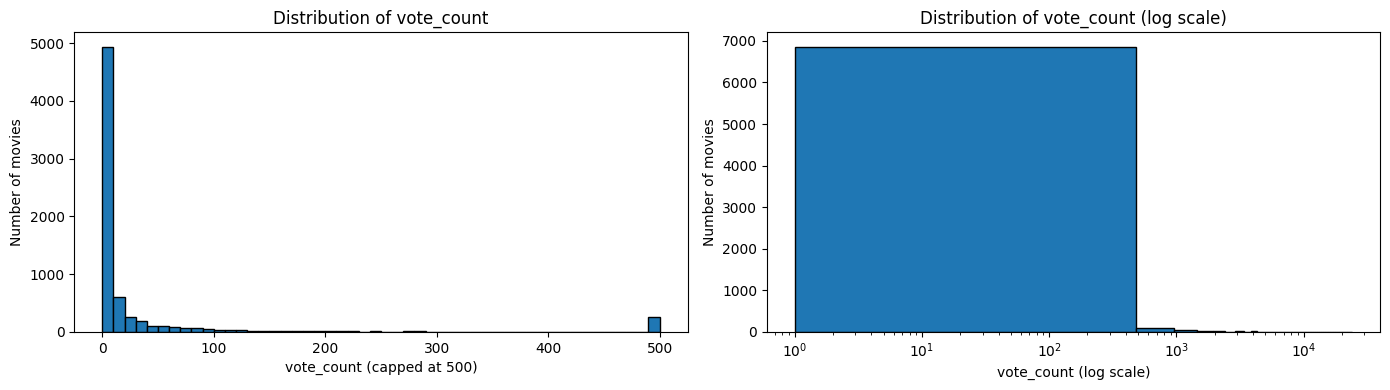


Conclusion: a uniform threshold would heavily penalize non-anglophone cinemas.
    We will use an adaptive threshold per country.


In [13]:
import matplotlib.pyplot as plt

# Analyze vote_count distribution to inform our filtering strategy

print("Median vote_count by country:\n")
print(df.groupby('origin_country_name')['vote_count'].agg(['median', 'mean', 'count']).round(1))

print("\nMovies kept per country at different thresholds:\n")
print(f"{'Country':<20} {'Total':<10} {'>=5':<8} {'>=10':<8} {'>=20':<8}")
print("-" * 60)
for country in df['origin_country_name'].unique():
    subset = df[df['origin_country_name'] == country]
    total = len(subset)
    over_5 = (subset['vote_count'] >= 5).sum()
    over_10 = (subset['vote_count'] >= 10).sum()
    over_20 = (subset['vote_count'] >= 20).sum()
    print(f"{country:<20} {total:<10} {over_5:<8} {over_10:<8} {over_20:<8}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['vote_count'].clip(upper=500), bins=50, edgecolor='black')
axes[0].set_xlabel('vote_count (capped at 500)')
axes[0].set_ylabel('Number of movies')
axes[0].set_title('Distribution of vote_count')

axes[1].hist(df['vote_count'].clip(lower=1), bins=50, edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('vote_count (log scale)')
axes[1].set_ylabel('Number of movies')
axes[1].set_title('Distribution of vote_count (log scale)')

plt.tight_layout()
plt.show()

print("\nConclusion: a uniform threshold would heavily penalize non-anglophone cinemas.")
print("    We will use an adaptive threshold per country.")

In [14]:
# Movies without overview can't be matched to a conflict later

before = len(df)
df = df.dropna(subset=['overview'])
after = len(df)

print(f"Removed {before - after} movies without overview")
print(f"Remaining: {after} movies")

Removed 461 movies without overview
Remaining: 6662 movies


In [15]:
# Some films appear multiple times (for example a UK-French co-production appears once with origin_country=GB, once with FR).
# Strategy: keep one row per film, but list all origin countries.

duplicate_count = df.duplicated(subset='id').sum()
print(f"Found {duplicate_count} duplicate films (same TMDB id, different origin country)")

df_grouped = df.groupby('id').agg({
    'title': 'first',
    'original_title': 'first',
    'original_language': 'first',
    'release_date': 'first',
    'release_year': 'first',
    'decade': 'first',
    'overview': 'first',
    'popularity': 'first',
    'vote_average': 'first',
    'vote_count': 'first',
    'origin_country_code': lambda x: ','.join(sorted(set(x))),
    'origin_country_name': lambda x: ','.join(sorted(set(x))),
    'genre_ids': 'first'
}).reset_index()

# Create a 'primary_country' column (first country alphabetically)
# This is used for analysis grouping; the full list is preserved
df_grouped['primary_country'] = df_grouped['origin_country_code'].str.split(',').str[0]

print(f"After deduplication: {df_grouped.shape[0]} unique films")
print(f"\n Films with multi-country co-productions:")
multi_country = df_grouped[df_grouped['origin_country_code'].str.contains(',')]
print(f"   {len(multi_country)} films are co-productions")

Found 460 duplicate films (same TMDB id, different origin country)
After deduplication: 6202 unique films

 Films with multi-country co-productions:
   439 films are co-productions


In [16]:
# Adaptive filtering: minimum 5 votes AND top 60% per country
# Rationale:
# - The absolute minimum (5 votes) removes ghost entries and abandoned productions
# - The country-level threshold (top 60%) ensures fair representation across cinema industries, regardless of TMDB's anglo-centric audience bias

MIN_VOTES_ABSOLUTE = 5
QUANTILE_THRESHOLD = 0.40  # keep movies above this percentile within their country

before = len(df_grouped)

# Compute per-country threshold and apply both filters
df_grouped['country_threshold'] = df_grouped.groupby('primary_country')['vote_count'].transform(
    lambda x: x.quantile(QUANTILE_THRESHOLD)
)

df_filtered = df_grouped[
    (df_grouped['vote_count'] >= MIN_VOTES_ABSOLUTE) &
    (df_grouped['vote_count'] >= df_grouped['country_threshold'])
].copy()

# Drop the temporary threshold column
df_filtered = df_filtered.drop(columns=['country_threshold'])

after = len(df_filtered)

print(f"Removed {before - after} movies")
print(f"   Filters applied:")
print(f"   - vote_count >= {MIN_VOTES_ABSOLUTE} (absolute minimum)")
print(f"   - vote_count >= {int(QUANTILE_THRESHOLD*100)}th percentile within country")
print(f"Remaining: {after} movies\n")

print("Movies kept per country after adaptive filtering:")
print(df_filtered['primary_country'].value_counts())

print("\n Country share of final dataset:")
shares = (df_filtered['primary_country'].value_counts(normalize=True) * 100).round(1)
print(shares.astype(str) + '%')

Removed 3519 movies
   Filters applied:
   - vote_count >= 5 (absolute minimum)
   - vote_count >= 40th percentile within country
Remaining: 2683 movies

Movies kept per country after adaptive filtering:
primary_country
US    1241
GB     489
RU     349
FR     295
DE     157
JP     152
Name: count, dtype: int64

 Country share of final dataset:
primary_country
US    46.3%
GB    18.2%
RU    13.0%
FR    11.0%
DE     5.9%
JP     5.7%
Name: proportion, dtype: object


In [17]:
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['release_year'] >= 1945].copy()
after = len(df_filtered)

print(f"🗑️ Removed {before - after} movies released before 1945")
print(f"📦 Remaining: {after} movies")

🗑️ Removed 340 movies released before 1945
📦 Remaining: 2343 movies


Cleaned dataset: 2343 movies

Movies per primary origin country:
primary_country
US    1009
GB     433
RU     319
FR     289
JP     148
DE     145
Name: count, dtype: int64

Movies per decade:
decade
1940    103
1950    311
1960    326
1970    188
1980    240
1990    186
2000    320
2010    449
2020    220
Name: count, dtype: int64


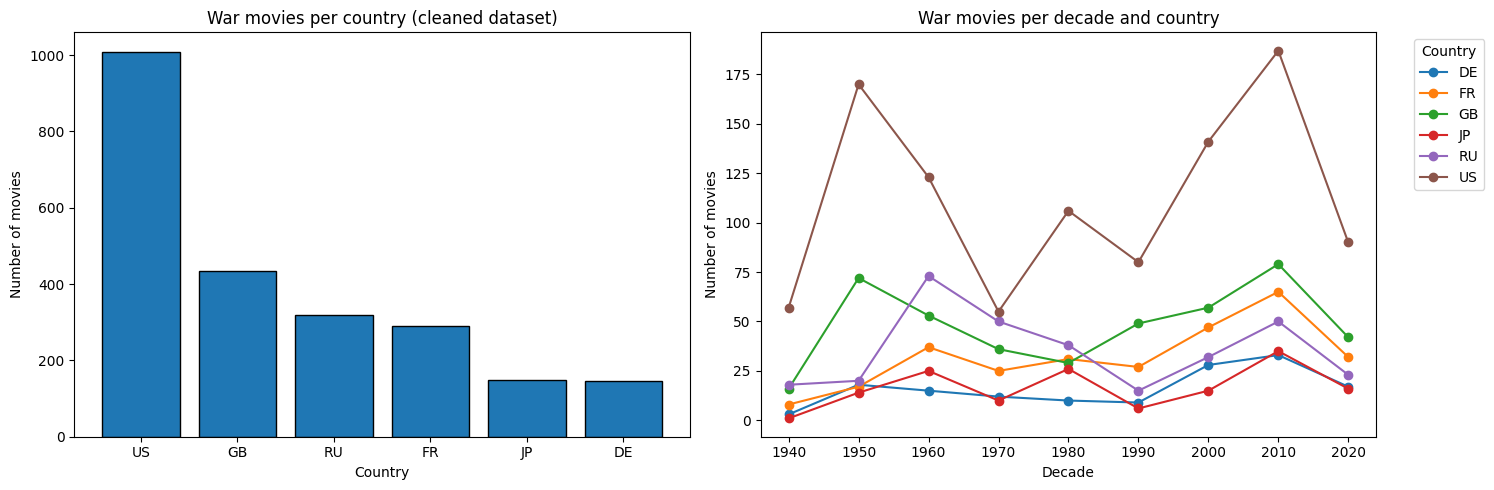

In [18]:
# Final dataset summary
print(f"Cleaned dataset: {df_filtered.shape[0]} movies\n")

print("Movies per primary origin country:")
print(df_filtered['primary_country'].value_counts())

print("\nMovies per decade:")
print(df_filtered['decade'].value_counts().sort_index())

# Visualization: movies per country and per decade
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: bar chart by country
country_counts = df_filtered['primary_country'].value_counts()
axes[0].bar(country_counts.index, country_counts.values, edgecolor='black')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of movies')
axes[0].set_title('War movies per country (cleaned dataset)')

# Right: line chart by decade
decade_counts = df_filtered.groupby(['decade', 'primary_country']).size().unstack(fill_value=0)
decade_counts.plot(ax=axes[1], marker='o')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Number of movies')
axes[1].set_title('War movies per decade and country')
axes[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [19]:
# Save cleaned dataset locally
output_path = 'war_movies_cleaned.csv'
df_filtered.to_csv(output_path, index=False, encoding='utf-8')

print(f"Saved: {output_path}")
print(f"Final size: {df_filtered.shape[0]} movies, {df_filtered.shape[1]} columns")
print(f"\nFinal columns: {df_filtered.columns.tolist()}")

Saved: war_movies_cleaned.csv
Final size: 2343 movies, 15 columns

Final columns: ['id', 'title', 'original_title', 'original_language', 'release_date', 'release_year', 'decade', 'overview', 'popularity', 'vote_average', 'vote_count', 'origin_country_code', 'origin_country_name', 'genre_ids', 'primary_country']


In [20]:
from google.colab import files
files.download('war_movies_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>